# Gut Microbiome Diversity — QC Report (Alternative Metrics)
#
Quality control report comparing multiple alpha diversity metrics.
#
**Generated:** 2026-02-23
**Fork:** alternative-metrics (explores Simpson, Chao1 alongside Shannon)
**Output table:** `ds.polaris.gut_microbiome_diversity`
**Participants:** 12,302

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from databricks import sql
from dotenv import load_dotenv

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Load environment
load_dotenv()

True

In [2]:
# Connect to Databricks
connection = sql.connect(
    server_hostname=os.getenv("DATABRICKS_HOST").replace("https://", "").rstrip("/"),
    http_path=f"/sql/1.0/warehouses/{os.getenv('DATABRICKS_SQL_WAREHOUSE_ID')}",
    access_token=os.getenv("DATABRICKS_TOKEN"),
)

[WARN] pyarrow is not installed by default since databricks-sql-connector 4.0.0,any arrow specific api (e.g. fetchmany_arrow) and cloud fetch will be disabled.If you need these features, please run pip install pyarrow or pip install databricks-sql-connector[pyarrow] to install


In [3]:
# Load output data
query = "SELECT * FROM ds.polaris.gut_microbiome_diversity"
cursor = connection.cursor()
cursor.execute(query)
df = pd.DataFrame(cursor.fetchall(), columns=[desc[0] for desc in cursor.description])
cursor.close()

# Convert numeric columns from Decimal to float
numeric_cols = ['gut_microbiome_diversity__shannon_index',
                'gut_microbiome_diversity__simpson_index',
                'gut_microbiome_diversity__observed_species',
                'gut_microbiome_diversity__chao1_richness']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Loaded {len(df):,} participants from output table")
df.head()

Loaded 12,302 participants from output table


,participant_uuid,gut_microbiome_diversity__shannon_index,gut_microbiome_diversity__simpson_index,gut_microbiome_diversity__observed_species,gut_microbiome_diversity__chao1_richness,gut_microbiome_diversity__diversity_category,gut_microbiome_diversity__quality_flag
0,00042acf-e5b1-47a7-a222-7bf36a2f030b,3.827752,0.956298,179,311.480769,Normal diversity,Adequate
1,0005230a-9749-4535-9555-430d08c16444,2.203487,0.779089,114,373.200000,Low diversity,Adequate
2,00094024-061a-4676-abab-d038a08b6487,3.595566,0.951901,161,337.086957,Normal diversity,Adequate
3,00099288-b67b-44d4-abab-aff3e7abc0fc,4.164131,0.972059,248,704.333333,Normal diversity,Adequate
4,0009bcb8-80ca-4eae-a666-c3a613a9e6d3,3.954148,0.967061,171,411.142857,Normal diversity,Adequate


## Feature Summary

In [4]:
# Basic stats
print("=" * 80)
print("FEATURE SUMMARY")
print("=" * 80)
print(f"\nTotal participants: {len(df):,}")
print(f"\nColumns:")
for col in df.columns:
    print(f"  - {col}")

FEATURE SUMMARY

Total participants: 12,302

Columns:
  - participant_uuid
  - gut_microbiome_diversity__shannon_index
  - gut_microbiome_diversity__simpson_index
  - gut_microbiome_diversity__observed_species
  - gut_microbiome_diversity__chao1_richness
  - gut_microbiome_diversity__diversity_category
  - gut_microbiome_diversity__quality_flag


In [5]:
# All diversity metrics statistics
metrics = {
    'gut_microbiome_diversity__shannon_index': 'Shannon Index',
    'gut_microbiome_diversity__simpson_index': 'Simpson Index',
    'gut_microbiome_diversity__observed_species': 'Observed Species',
    'gut_microbiome_diversity__chao1_richness': 'Chao1 Richness'
}

for col, name in metrics.items():
    print(f"\n{name}:")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std: {df[col].std():.2f}")
    print(f"  Min: {df[col].min():.2f}")
    print(f"  Max: {df[col].max():.2f}")
    print(f"  Missing: {df[col].isna().sum()} ({df[col].isna().sum()/len(df)*100:.1f}%)")


Shannon Index:
  Mean: 3.72
  Median: 3.84
  Std: 0.60
  Min: 0.62
  Max: 4.97
  Missing: 0 (0.0%)

Simpson Index:
  Mean: 0.93
  Median: 0.95
  Std: 0.08
  Min: 0.23
  Max: 0.99
  Missing: 0 (0.0%)

Observed Species:
  Mean: 205.16
  Median: 204.00
  Std: 64.29
  Min: 5.00
  Max: 476.00
  Missing: 0 (0.0%)

Chao1 Richness:
  Mean: 464.58
  Median: 448.12
  Std: 191.96
  Min: 7.00
  Max: 2068.56
  Missing: 0 (0.0%)


## Phenotype Distribution

In [6]:
# Diversity category distribution
div_cat_col = 'gut_microbiome_diversity__diversity_category'
print(f"\n{div_cat_col}:")
print(df[div_cat_col].value_counts())
print(f"\nProportions:")
print(df[div_cat_col].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))


gut_microbiome_diversity__diversity_category:
gut_microbiome_diversity__diversity_category
Normal diversity    10795
Low diversity        1507
Name: count, dtype: int64

Proportions:
gut_microbiome_diversity__diversity_category
Normal diversity    87.7%
Low diversity       12.3%
Name: proportion, dtype: object


In [7]:
# Quality flag distribution (updated threshold: >50 species)
qual_col = 'gut_microbiome_diversity__quality_flag'
print(f"\n{qual_col} (threshold: >50 species for Adequate):")
print(df[qual_col].value_counts())
print(f"\nProportions:")
print(df[qual_col].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))


gut_microbiome_diversity__quality_flag (threshold: >50 species for Adequate):
gut_microbiome_diversity__quality_flag
Adequate                 12278
Low quality/dysbiotic       24
Name: count, dtype: int64

Proportions:
gut_microbiome_diversity__quality_flag
Adequate                 99.8%
Low quality/dysbiotic     0.2%
Name: proportion, dtype: object


## Visual Summaries

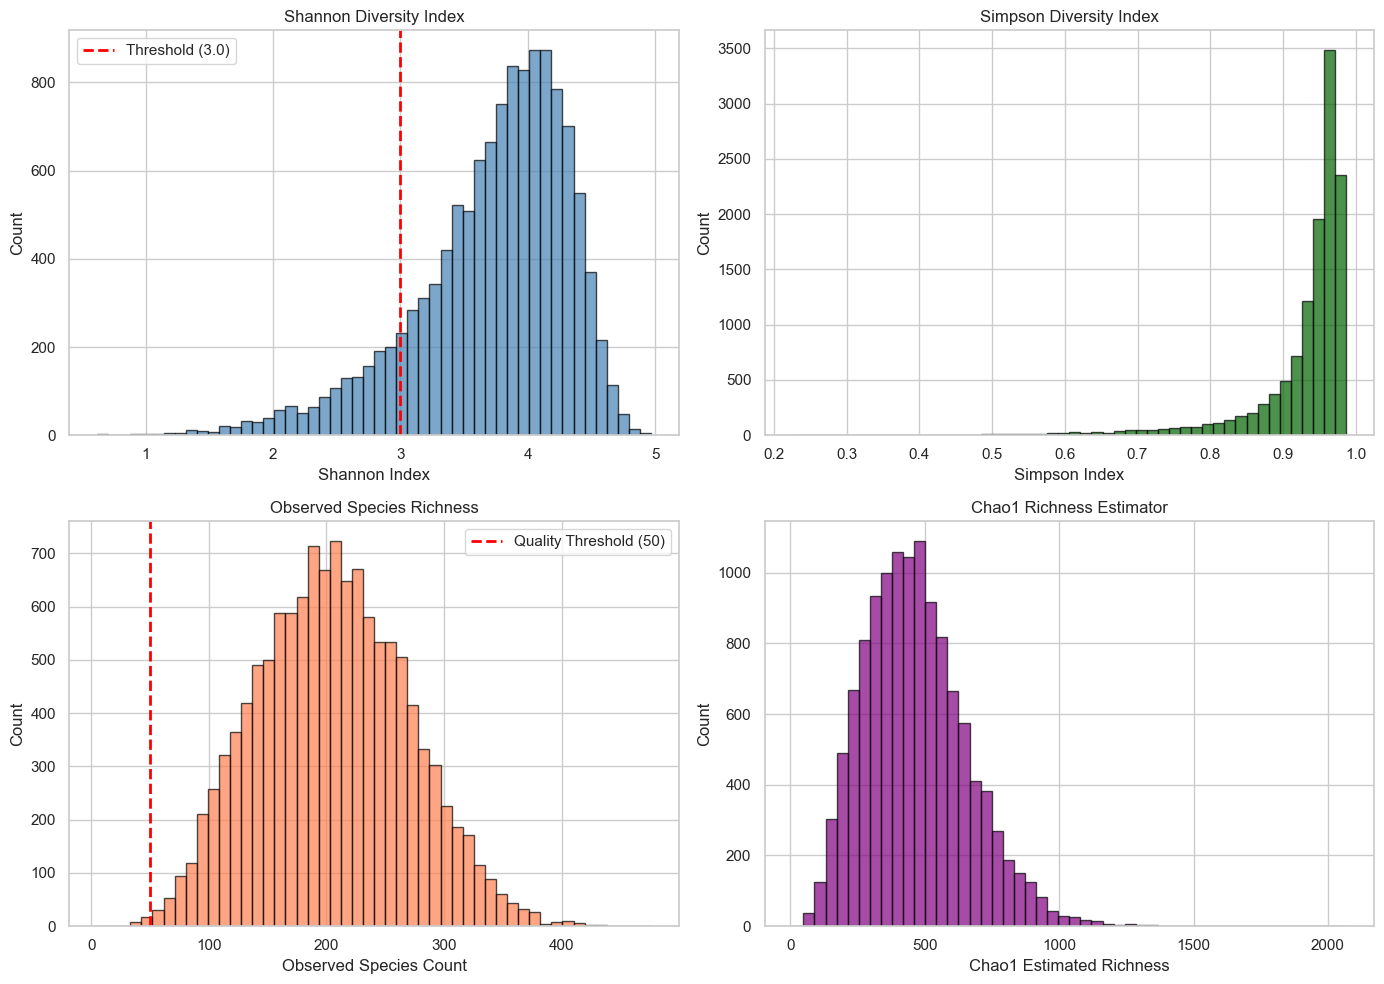

In [8]:
# Distribution comparison: all 4 metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Shannon
axes[0,0].hist(df['gut_microbiome_diversity__shannon_index'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].axvline(3.0, color='red', linestyle='--', linewidth=2, label='Threshold (3.0)')
axes[0,0].set_xlabel('Shannon Index')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Shannon Diversity Index')
axes[0,0].legend()

# Simpson
axes[0,1].hist(df['gut_microbiome_diversity__simpson_index'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='darkgreen')
axes[0,1].set_xlabel('Simpson Index')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Simpson Diversity Index')

# Observed species
axes[1,0].hist(df['gut_microbiome_diversity__observed_species'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1,0].axvline(50, color='red', linestyle='--', linewidth=2, label='Quality Threshold (50)')
axes[1,0].set_xlabel('Observed Species Count')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Observed Species Richness')
axes[1,0].legend()

# Chao1
axes[1,1].hist(df['gut_microbiome_diversity__chao1_richness'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1,1].set_xlabel('Chao1 Estimated Richness')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Chao1 Richness Estimator')

plt.tight_layout()
plt.show()

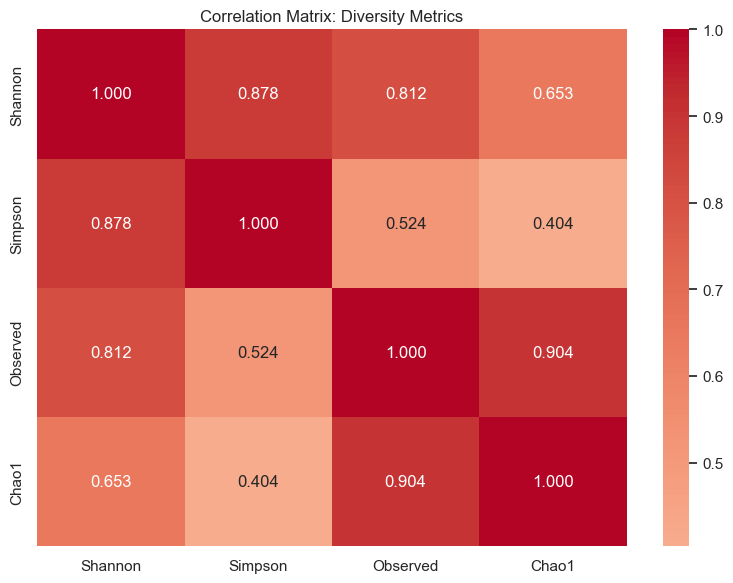

In [9]:
# Correlation heatmap between metrics
fig, ax = plt.subplots(figsize=(8, 6))
corr_cols = ['gut_microbiome_diversity__shannon_index',
             'gut_microbiome_diversity__simpson_index',
             'gut_microbiome_diversity__observed_species',
             'gut_microbiome_diversity__chao1_richness']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            xticklabels=['Shannon', 'Simpson', 'Observed', 'Chao1'],
            yticklabels=['Shannon', 'Simpson', 'Observed', 'Chao1'],
            ax=ax)
ax.set_title('Correlation Matrix: Diversity Metrics')
plt.tight_layout()
plt.show()

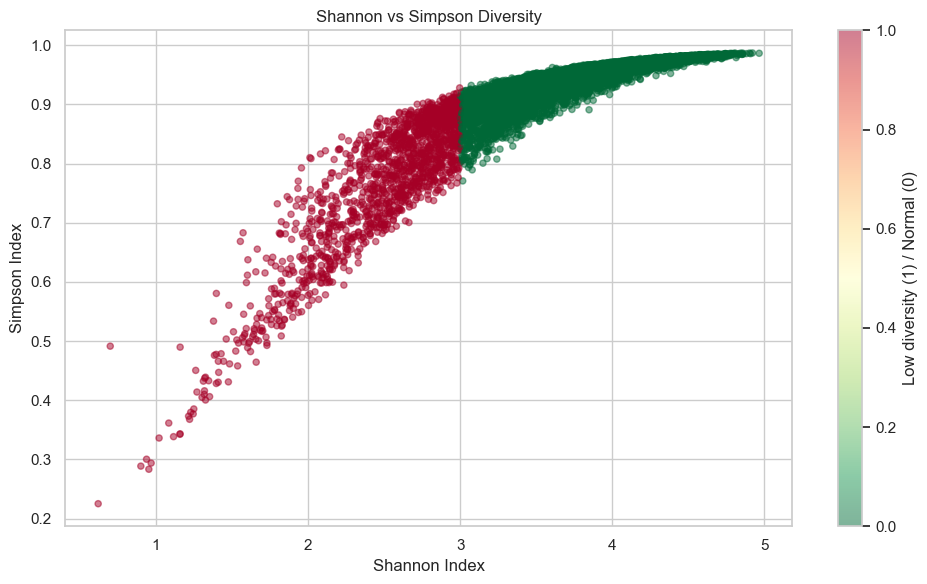

In [10]:
# Shannon vs Simpson scatter
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['gut_microbiome_diversity__shannon_index'],
                     df['gut_microbiome_diversity__simpson_index'],
                     c=(df[div_cat_col] == 'Low diversity').astype(int),
                     cmap='RdYlGn_r', alpha=0.5, s=20)
ax.set_xlabel('Shannon Index')
ax.set_ylabel('Simpson Index')
ax.set_title('Shannon vs Simpson Diversity')
plt.colorbar(scatter, label='Low diversity (1) / Normal (0)', ax=ax)
plt.tight_layout()
plt.show()

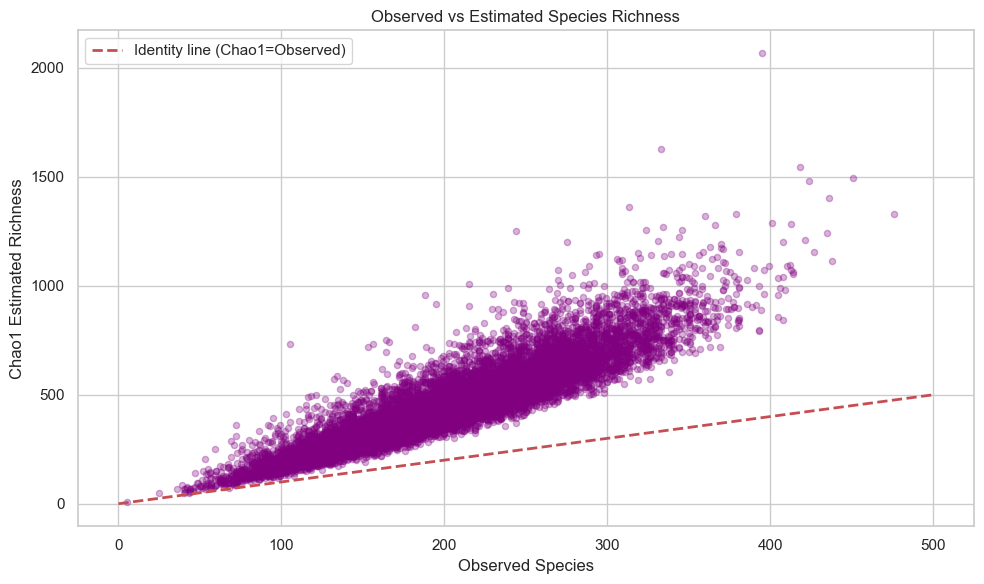

In [11]:
# Observed vs Chao1 richness
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['gut_microbiome_diversity__observed_species'],
           df['gut_microbiome_diversity__chao1_richness'],
           alpha=0.3, s=20, color='purple')
ax.plot([0, 500], [0, 500], 'r--', linewidth=2, label='Identity line (Chao1=Observed)')
ax.set_xlabel('Observed Species')
ax.set_ylabel('Chao1 Estimated Richness')
ax.set_title('Observed vs Estimated Species Richness')
ax.legend()
plt.tight_layout()
plt.show()

## Missingness Analysis

In [12]:
print("=" * 80)
print("MISSINGNESS ANALYSIS")
print("=" * 80)
for col in df.columns:
    missing = df[col].isna().sum()
    print(f"{col}: {missing} ({missing/len(df)*100:.2f}%)")

MISSINGNESS ANALYSIS
participant_uuid: 0 (0.00%)
gut_microbiome_diversity__shannon_index: 0 (0.00%)
gut_microbiome_diversity__simpson_index: 0 (0.00%)
gut_microbiome_diversity__observed_species: 0 (0.00%)
gut_microbiome_diversity__chao1_richness: 0 (0.00%)
gut_microbiome_diversity__diversity_category: 0 (0.00%)
gut_microbiome_diversity__quality_flag: 0 (0.00%)


## Cross-Tabulations

In [13]:
print("\n" + "=" * 80)
print("CROSS-TABULATION: Diversity Category × Quality Flag")
print("=" * 80)
crosstab = pd.crosstab(df[div_cat_col], df[qual_col], margins=True)
print(crosstab)

print("\nProportions within diversity categories:")
crosstab_pct = pd.crosstab(df[div_cat_col], df[qual_col], normalize='index')
print(crosstab_pct.apply(lambda x: x.map(lambda v: f"{v*100:.1f}%")))


CROSS-TABULATION: Diversity Category × Quality Flag
gut_microbiome_diversity__quality_flag        Adequate  Low quality/dysbiotic  \
gut_microbiome_diversity__diversity_category                                    
Low diversity                                     1483                     24   
Normal diversity                                 10795                      0   
All                                              12278                     24   

gut_microbiome_diversity__quality_flag          All  
gut_microbiome_diversity__diversity_category         
Low diversity                                  1507  
Normal diversity                              10795  
All                                           12302  

Proportions within diversity categories:
gut_microbiome_diversity__quality_flag       Adequate Low quality/dysbiotic
gut_microbiome_diversity__diversity_category                               
Low diversity                                   98.4%                  1.6%
N

## Metric Comparison Summary

In [14]:
# Compare classifications
print("\n" + "=" * 80)
print("METRIC COMPARISON")
print("=" * 80)

# Low diversity by Shannon vs high Simpson
low_shannon = df['gut_microbiome_diversity__shannon_index'] < 3.0
high_simpson = df['gut_microbiome_diversity__simpson_index'] > 0.95

print(f"\nLow Shannon (<3.0): {low_shannon.sum():,} ({low_shannon.sum()/len(df)*100:.1f}%)")
print(f"High Simpson (>0.95): {high_simpson.sum():,} ({high_simpson.sum()/len(df)*100:.1f}%)")
print(f"Both low Shannon AND high Simpson: {(low_shannon & high_simpson).sum():,}")
print(f"Low Shannon but NOT high Simpson: {(low_shannon & ~high_simpson).sum():,}")

# Chao1 inflation over observed
chao1_ratio = df['gut_microbiome_diversity__chao1_richness'] / df['gut_microbiome_diversity__observed_species']
print(f"\nChao1/Observed ratio:")
print(f"  Mean: {chao1_ratio.mean():.2f}x")
print(f"  Median: {chao1_ratio.median():.2f}x")
print(f"  >3x inflation: {(chao1_ratio > 3).sum():,} participants ({(chao1_ratio > 3).sum()/len(df)*100:.1f}%)")


METRIC COMPARISON

Low Shannon (<3.0): 1,507 (12.3%)
High Simpson (>0.95): 6,822 (55.5%)
Both low Shannon AND high Simpson: 0
Low Shannon but NOT high Simpson: 1,507

Chao1/Observed ratio:
  Mean: 2.22x
  Median: 2.17x
  >3x inflation: 575 participants (4.7%)


## Summary Statistics Table

In [15]:
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Participants',
        'Shannon Index (mean ± std)',
        'Simpson Index (mean ± std)',
        'Observed Species (mean ± std)',
        'Chao1 Richness (mean ± std)',
        'Low Diversity Count (%)',
        'Normal Diversity Count (%)',
        'Low Quality Count (%) [>50 threshold]',
        'Adequate Quality Count (%)',
    ],
    'Value': [
        f"{len(df):,}",
        f"{df['gut_microbiome_diversity__shannon_index'].mean():.2f} ± {df['gut_microbiome_diversity__shannon_index'].std():.2f}",
        f"{df['gut_microbiome_diversity__simpson_index'].mean():.3f} ± {df['gut_microbiome_diversity__simpson_index'].std():.3f}",
        f"{df['gut_microbiome_diversity__observed_species'].mean():.1f} ± {df['gut_microbiome_diversity__observed_species'].std():.1f}",
        f"{df['gut_microbiome_diversity__chao1_richness'].mean():.1f} ± {df['gut_microbiome_diversity__chao1_richness'].std():.1f}",
        f"{(df[div_cat_col]=='Low diversity').sum():,} ({(df[div_cat_col]=='Low diversity').sum()/len(df)*100:.1f}%)",
        f"{(df[div_cat_col]=='Normal diversity').sum():,} ({(df[div_cat_col]=='Normal diversity').sum()/len(df)*100:.1f}%)",
        f"{(df[qual_col]=='Low quality/dysbiotic').sum():,} ({(df[qual_col]=='Low quality/dysbiotic').sum()/len(df)*100:.1f}%)",
        f"{(df[qual_col]=='Adequate').sum():,} ({(df[qual_col]=='Adequate').sum()/len(df)*100:.1f}%)",
    ]
})
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(summary_stats.to_string(index=False))


SUMMARY STATISTICS
                               Metric          Value
                   Total Participants         12,302
           Shannon Index (mean ± std)    3.72 ± 0.60
           Simpson Index (mean ± std)  0.928 ± 0.077
        Observed Species (mean ± std)   205.2 ± 64.3
          Chao1 Richness (mean ± std)  464.6 ± 192.0
              Low Diversity Count (%)  1,507 (12.3%)
           Normal Diversity Count (%) 10,795 (87.7%)
Low Quality Count (%) [>50 threshold]      24 (0.2%)
           Adequate Quality Count (%) 12,278 (99.8%)


In [16]:
# Close connection
connection.close()
print("\n✓ QC report complete")


✓ QC report complete
